In [7]:
import torch
torch.cuda.is_available()

True

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Import the libraries**

In [9]:
#for adding augemented dataset into the main train folder

import os
import shutil


#data loading and building model
from PIL import Image
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader


#for visualization
import matplotlib.pyplot as plt

#Import PyTorch model tools
import torch.nn as nn
import torch.nn.functional as F

#for classifcation
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np



## **1. Data Loading in the drive**

In [10]:
data_path = "/content/drive/MyDrive/ GAN_Xray_Project/chest_xray"

In [11]:
print(os.listdir(data_path))
train_path = os.path.join(data_path, "train")
print(os.listdir(train_path))

normal_count = len(os.listdir(os.path.join(train_path, "NORMAL")))
pneumonia_count = len(os.listdir(os.path.join(train_path, "PNEUMONIA")))

print("NORMAL images in train set:", normal_count)
print("PNEUMONIA images in train set:", pneumonia_count)

['.DS_Store', 'val', 'train', 'test']
['.DS_Store', 'PNEUMONIA', 'NORMAL']
NORMAL images in train set: 1342
PNEUMONIA images in train set: 3876


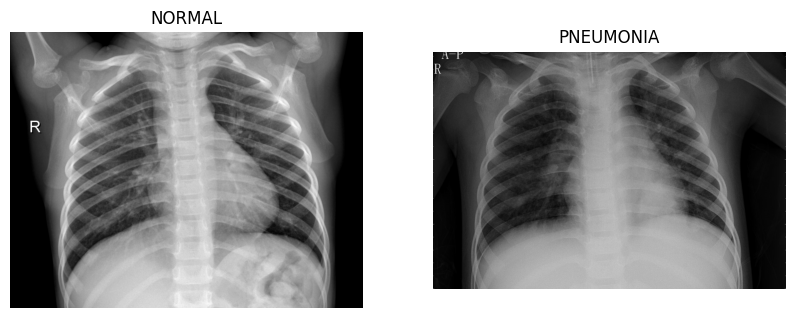

In [12]:
normal_folder = os.path.join(train_path, "NORMAL")
pneumonia_folder = os.path.join(train_path, "PNEUMONIA")

normal_image_name = os.listdir(normal_folder)[0]
pneumonia_image_name = os.listdir(pneumonia_folder)[0]

normal_image_path = os.path.join(normal_folder, normal_image_name)
pneumonia_image_path = os.path.join(pneumonia_folder, pneumonia_image_name)

normal_img = Image.open(normal_image_path)
pneumonia_img = Image.open(pneumonia_image_path)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(normal_img, cmap="gray")
plt.title("NORMAL")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(pneumonia_img, cmap="gray")
plt.title("PNEUMONIA")
plt.axis("off")

plt.show()

**Key Takeaways:**

- The chest X-ray dataset was loaded successfully from Google Drive
- The training set contains 1342 NORMAL images and 3876 PNEUMONIA images
- The dataset is imbalanced, with significantly more pneumonia images than normal images
- This class imbalance motivates the use of augmentation

## **2. Loading & Preprocessing X-ray images**

In [13]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

**2.1 Create the image transform**

In [14]:
# ✅ Add random flips and rotation — makes model more robust
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),        # flip image randomly
    transforms.RandomRotation(10),            # rotate slightly
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

**2.2 Create dataset objects**

In [15]:
train_dataset = datasets.ImageFolder(root=data_path + "/train", transform=transform)
val_dataset = datasets.ImageFolder(root=data_path + "/val", transform=transform)
test_dataset = datasets.ImageFolder(root=data_path + "/test", transform=transform)

- We use ImageFolder from PyTorch library because it automatically loads images and assigns labels based on folder names.

In [16]:
print("Classes:", train_dataset.classes)
print("Class to index:", train_dataset.class_to_idx)

Classes: ['NORMAL', 'PNEUMONIA']
Class to index: {'NORMAL': 0, 'PNEUMONIA': 1}


**2.3 Create dataloaders**

In [17]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

- Instead of giving 5,000 images at once, dataloader gives 32 images then next 32 then next 32

In [18]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("First 10 labels:", labels[:10])

Image batch shape: torch.Size([64, 1, 64, 64])
Label batch shape: torch.Size([64])
First 10 labels: tensor([0, 1, 1, 1, 1, 0, 1, 1, 0, 1])


- images -> 32 X-ray images
- labels ->	32 numbers (0 or 1)

**Key Takeaways:**

1. Images were converted to grayscale, resized to 64 × 64, converted to tensors, and normalized
2. The dataset contains 2 classes: NORMAL and PNEUMONIA
3. Class mapping was:
- NORMAL = 0
- PNEUMONIA = 1
4. A sample training batch confirmed the input shape as [64, 1, 64, 64]
5. This confirms that the images were correctly prepared for CNN and GAN training

## **3. Build the baseline CNN**

**3.1 Define the CNN model**

In [19]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()

        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.fc1 = nn.Linear(64 * 8 * 8, 128)
        self.dropout = nn.Dropout(0.5)   # ✅ ADD THIS LINE
        self.fc2 = nn.Linear(128, 2)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))

        x = x.view(-1, 64 * 8 * 8)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)              # ✅ ADD THIS LINE
        x = self.fc2(x)

        return x

**3.2 Create the model**

In [20]:
model = SimpleCNN()
#bringing model to gpu to run
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
print(model)


SimpleCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=4096, out_features=128, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=128, out_features=2, bias=True)
)


1. The model SimpleCNN was successfully created and printed.
2. The model consists of 3 convolutional layers:
- conv1: takes grayscale input (1 channel) and produces 16 feature maps
- conv2: increases features from 16 to 32
- conv3: increases features from 32 to 64
4. A MaxPooling layer is used after each convolution:
- reduces image size
- keeps important features
5. The model includes 2 fully connected (dense) layers:
- fc1: converts features into 128 neurons
- fc2: final output layer with 2 outputs
6. The final output represents:
- Class 0 → NORMAL
- Class 1 → PNEUMONIA
- The architecture is suitable for image classification tasks
- The model is ready to be trained on the chest X-ray dataset-

In [21]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

- **CrossEntropyLoss:** Used for classification with 2 or more classes (NORMAL & PNEUMONIA)

- **Adam:** This is the optimizer.It helps the model update its weights and learn.

- **lr=0.001**: This is the learning rate.


**3.3 Test the model on one batch**

In [22]:
images, labels = next(iter(train_loader))

images = images.to(device)
labels = labels.to(device)

outputs = model(images)

print("Output shape:", outputs.shape)

Output shape: torch.Size([64, 2])


**3.4 Train the model on all batches (test and validation set) for 10 epochs**

In [24]:
train_losses = []
val_losses = []
val_accuracies = []

num_epochs = 10

for epoch in range(num_epochs):

    # ----- TRAINING -----
    model.train()
    total_train_loss = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # ----- VALIDATION -----
    model.eval()
    total_val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    avg_val_loss = total_val_loss / len(val_loader)
    val_accuracy = 100 * correct / total

    val_losses.append(avg_val_loss)
    val_accuracies.append(val_accuracy)

    print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Accuracy: {val_accuracy:.2f}%")


Epoch [1/10] | Train Loss: 0.1834 | Val Loss: 1.7970 | Val Accuracy: 50.00%
Epoch [2/10] | Train Loss: 0.1477 | Val Loss: 0.7072 | Val Accuracy: 68.75%
Epoch [3/10] | Train Loss: 0.1354 | Val Loss: 0.3619 | Val Accuracy: 81.25%
Epoch [4/10] | Train Loss: 0.1173 | Val Loss: 0.4877 | Val Accuracy: 81.25%
Epoch [5/10] | Train Loss: 0.1066 | Val Loss: 0.8767 | Val Accuracy: 62.50%
Epoch [6/10] | Train Loss: 0.1127 | Val Loss: 0.5999 | Val Accuracy: 62.50%
Epoch [7/10] | Train Loss: 0.0945 | Val Loss: 0.6069 | Val Accuracy: 68.75%
Epoch [8/10] | Train Loss: 0.0879 | Val Loss: 0.5191 | Val Accuracy: 75.00%
Epoch [9/10] | Train Loss: 0.0820 | Val Loss: 0.5143 | Val Accuracy: 75.00%
Epoch [10/10] | Train Loss: 0.0865 | Val Loss: 0.3945 | Val Accuracy: 75.00%


**Key Takeaways:**

- The baseline CNN was trained for 10 epochs
- Training loss decreased from 0.1834 to 0.0865, indicating that the model learned useful patterns from the training data
- Validation loss decreased overall from 1.7970 to 0.3945
- Validation accuracy improved from 50.00% to 75.00%, with a peak of 81.25%
- The model showed learning progress, but validation performance fluctuated across epochs

## **4 Evaluate Model**

**4.1 Training vs Validation Loss**

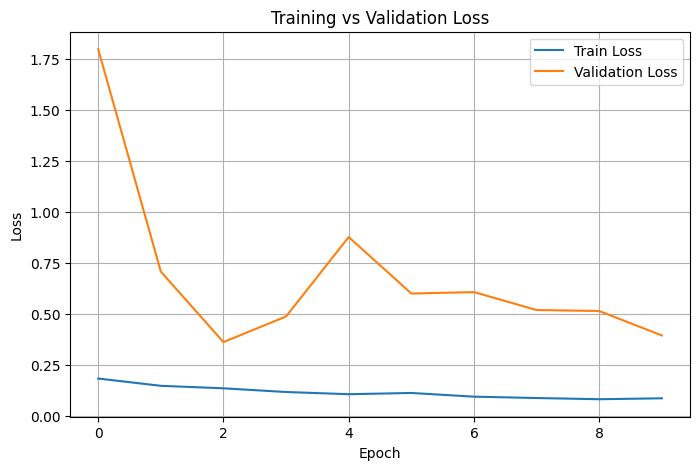

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.grid()

plt.show()

**4.2 Validation Accuracy**

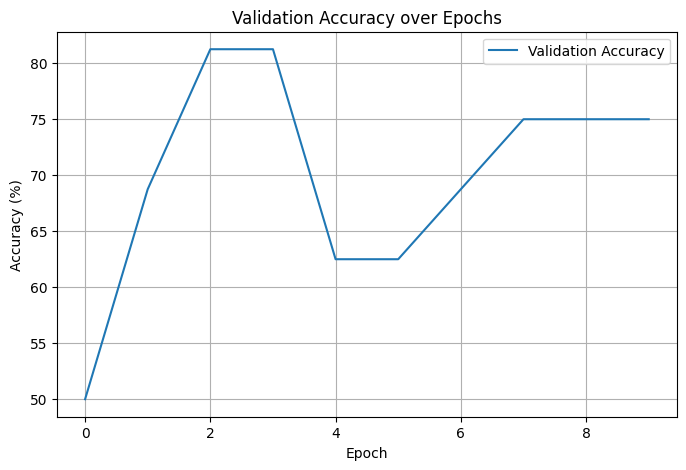

In [26]:
plt.figure(figsize=(8,5))

plt.plot(val_accuracies, label="Validation Accuracy")

plt.title("Validation Accuracy over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")

plt.legend()
plt.grid()

plt.show()

**4.3 Test Accuracy for test images**

In [27]:
model.eval()  # set model to evaluation mode

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 73.56%


**Key Takeaways:**

- The baseline CNN achieved a test accuracy of 73.56%
- This result will be used as the reference point for comparison after GAN-based augmentation
- The model showed decreasing training loss and reasonable classification performance on the test set

**4.4 Get predictions for all test images**

In [28]:
model.eval()

all_labels = []
all_preds = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(predicted.cpu().numpy())


**4.5 Confusion matrix**

In [29]:
cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[ 74 160]
 [  2 388]]


**Key Takeaways:**

- 74 NORMAL images were correctly classified
- 160 NORMAL images were incorrectly classified as PNEUMONIA
- 388 PNEUMONIA images were correctly classified
- Only 2 PNEUMONIA images were incorrectly classified as NORMAL

**4.6 Classification report**

In [30]:
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=train_dataset.classes))


Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.97      0.32      0.48       234
   PNEUMONIA       0.71      0.99      0.83       390

    accuracy                           0.74       624
   macro avg       0.84      0.66      0.65       624
weighted avg       0.81      0.74      0.70       624



**Key Takeaways:**

- The baseline model performed very well in detecting pneumonia, with recall = 0.99
- However, it performed poorly in identifying normal cases, with recall = 0.32
- This indicates a strong bias toward predicting PNEUMONIA
- The model achieved an overall accuracy of 73.56%

## **5. Create GAN dataset**

**5.1 Define GAN transforms**

In [31]:


gan_transform = transforms.Compose([
    transforms.Grayscale(),
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # VERY IMPORTANT
])

**5.2 Load dataset (only images)**

In [32]:
gan_dataset = datasets.ImageFolder(root="/content/drive/MyDrive/ GAN_Xray_Project/chest_xray/train", transform=gan_transform)

**Key Takeaway:**

- The training dataset was loaded for GAN training using ImageFolder
- Only the training images were used so that validation and test sets remain separate for evaluation
- Images were converted to grayscale, resized to 64 × 64, converted to tensors, and normalized
- Normalization was done using (0.5,), (0.5,) so that image values lie in the range [-1, 1]
- This preprocessing is important because the GAN generator typically produces outputs in the same normalized range
- The dataset is now ready to be passed into a GAN dataloader for batch-wise training

## **5.3 Create the GAN dataloader**

In [33]:
gan_loader = DataLoader(gan_dataset, batch_size=32, shuffle=True)

- This creates batches for GAN training.
- A slightly larger batch size is common for GAN training and helps training be smoother.
- Shuffle=True Because the GAN should see the images in random order, not always the same sequence.

**5.4 Test one GAN batch**

In [34]:
images, labels = next(iter(gan_loader))

print("GAN batch shape:", images.shape)
print("First 10 labels:", labels[:10])

GAN batch shape: torch.Size([32, 1, 64, 64])
First 10 labels: tensor([1, 1, 1, 1, 0, 1, 1, 1, 0, 1])


**Key Takeaways:**
- The GAN dataset was created using the training images only
- Images were loaded in batches of 32
- A sample batch confirmed the GAN input shape as [32, 1, 64, 64]
- This confirms that the images were correctly prepared for DCGAN training

## **6. Build the GAN (DCGAN)**

**6.1 Build the Generator**

In [35]:

class Generator(nn.Module):
    def __init__(self, latent_dim=100):
        super(Generator, self).__init__()

        self.model = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, 256, kernel_size=4, stride=1, padding=0, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(True),

            nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1, bias=False),
            nn.Tanh()
        )

    def forward(self, x):
        return self.model(x)

The Generator is the part that creates fake chest X-ray images from random noise.

**6.2 Test the generator**

In [36]:
latent_dim = 100
generator = Generator(latent_dim).to(device)

noise = torch.randn(64, latent_dim, 1, 1).to(device)
fake_images = generator(noise)

print("Fake image batch shape:", fake_images.shape)

Fake image batch shape: torch.Size([64, 1, 64, 64])


**Key Takeaways:**
- A Generator network was implemented for the GAN model
- The generator takes a random latent vector of size 100
- It uses transposed convolution layers to progressively upsample noise into an image
- The final output size of the generator is 1 × 64 × 64, matching the chest X-ray image dimensions
- A Tanh activation function is used at the output layer so generated images lie in the range [-1, 1]
- A test batch confirmed that the generator produces images of shape [64, 1, 64, 64]



- A Generator network was implemented as part of the GAN model to synthesize chest X-ray images
- The generator takes a random latent vector of size 100 as input
- This latent vector represents random noise from which images are generated
- The generator uses multiple ConvTranspose2d (transposed convolution) layers to progressively increase the spatial size of the input
- The input is upsampled step-by-step from 1×1 → 4×4 → 8×8 → 16×16 → 32×32 → 64×64
- As the spatial dimensions increase, the number of channels decreases from 256 → 128 → 64 → 32 → 1
- Higher channel sizes represent multiple learned feature maps, which are gradually combined into a single output image
- The final output of the generator is an image of shape [1, 64, 64], matching the dimensions of the chest X-ray dataset
- Batch Normalization is applied after each layer to stabilize training and improve convergence
- ReLU activation is used in intermediate layers to introduce non-linearity and help the model learn complex patterns
- A Tanh activation function is used in the final layer to ensure that the generated images have pixel values in the range [-1, 1]
- This output range matches the normalized range of real images, allowing the discriminator to fairly compare real and generated images
- A test run confirmed that the generator produces output of shape [batch_size, 1, 64, 64], validating correct implementation

## **7. Build the Discriminator**

In [37]:
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()

        self.model = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(256, 1, kernel_size=4, stride=1, padding=0),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

**7.1 Test the discriminator**

In [38]:
discriminator = Discriminator().to(device)

test_output = discriminator(fake_images)

print("Discriminator output shape:", test_output.shape)



Discriminator output shape: torch.Size([64, 1, 1, 1])


This means that the output has 64 images and each gets 1 probability

**Key Takeaways:**
- A Discriminator network was implemented to classify images as real or fake
- The discriminator takes input images of size [1, 64, 64]
- It uses multiple convolutional layers to progressively extract features and reduce spatial dimensions
- The number of channels increases from 32 → 64 → 128 → 256, capturing deeper image features
- A LeakyReLU activation function is used to improve gradient flow during training
- Batch Normalization is applied to stabilize learning
- The final output is a single value using a Sigmoid activation, representing the probability of the image being real
- A test confirmed the output shape as [batch_size, 1, 1, 1], indicating correct implementation

**7.2 Training generator and discriminator**

In [39]:
#BCE for Binary classification: real = 1 and fake = 0
criterion = nn.BCELoss()

#Setup loss + optimizers

optimizer_G = torch.optim.Adam(generator.parameters(), lr=0.0002)
optimizer_D = torch.optim.Adam(discriminator.parameters(), lr=0.0002)

def train_gan(generator, discriminator, gan_loader, optimizer_G, optimizer_D, criterion, device, latent_dim=100, num_epochs=20):
    g_losses = []
    d_losses = []

    generator.train()
    discriminator.train()

    for epoch in range(num_epochs):
        epoch_g_loss = 0
        epoch_d_loss = 0

        for images, _ in gan_loader:
            real_images = images.to(device)
            batch_size = real_images.size(0)

            real_labels = torch.ones(batch_size, 1, 1, 1).to(device)
            fake_labels = torch.zeros(batch_size, 1, 1, 1).to(device)

            # -------------------------
            # Train Discriminator
            # -------------------------
            outputs_real = discriminator(real_images)
            loss_real = criterion(outputs_real, real_labels)

            noise = torch.randn(batch_size, latent_dim, 1, 1).to(device)
            fake_images = generator(noise)

            outputs_fake = discriminator(fake_images.detach())
            loss_fake = criterion(outputs_fake, fake_labels)

            loss_D = loss_real + loss_fake

            optimizer_D.zero_grad()
            loss_D.backward()
            optimizer_D.step()

            # -------------------------
            # Train Generator
            # -------------------------
            noise = torch.randn(batch_size, latent_dim, 1, 1).to(device)
            fake_images = generator(noise)

            outputs = discriminator(fake_images)
            loss_G = criterion(outputs, real_labels)

            optimizer_G.zero_grad()
            loss_G.backward()
            optimizer_G.step()

            epoch_d_loss += loss_D.item()
            epoch_g_loss += loss_G.item()

        avg_d_loss = epoch_d_loss / len(gan_loader)
        avg_g_loss = epoch_g_loss / len(gan_loader)

        d_losses.append(avg_d_loss)
        g_losses.append(avg_g_loss)

        print(f"Epoch [{epoch+1}/{num_epochs}] | Loss D: {avg_d_loss:.4f} | Loss G: {avg_g_loss:.4f}")

    return g_losses, d_losses


# num_epochs = 5
# latent_dim = 100

g_losses, d_losses = train_gan(
    generator,
    discriminator,
    gan_loader,
    optimizer_G,
    optimizer_D,
    criterion,
    device,
    latent_dim=100,
    num_epochs=50
)

Epoch [1/50] | Loss D: 0.0552 | Loss G: 5.9864
Epoch [2/50] | Loss D: 0.0075 | Loss G: 7.4751
Epoch [3/50] | Loss D: 0.0968 | Loss G: 7.4521
Epoch [4/50] | Loss D: 0.0187 | Loss G: 6.8346
Epoch [5/50] | Loss D: 0.1544 | Loss G: 6.1216
Epoch [6/50] | Loss D: 0.1647 | Loss G: 6.0784
Epoch [7/50] | Loss D: 0.1207 | Loss G: 5.4215
Epoch [8/50] | Loss D: 0.1588 | Loss G: 6.1275
Epoch [9/50] | Loss D: 0.1494 | Loss G: 6.2535
Epoch [10/50] | Loss D: 0.1066 | Loss G: 5.8422
Epoch [11/50] | Loss D: 0.1434 | Loss G: 6.4964
Epoch [12/50] | Loss D: 0.1610 | Loss G: 6.3359
Epoch [13/50] | Loss D: 0.1210 | Loss G: 6.1884
Epoch [14/50] | Loss D: 0.1456 | Loss G: 5.9773
Epoch [15/50] | Loss D: 0.1513 | Loss G: 6.3954
Epoch [16/50] | Loss D: 0.1435 | Loss G: 6.1896
Epoch [17/50] | Loss D: 0.1253 | Loss G: 6.1908
Epoch [18/50] | Loss D: 0.1419 | Loss G: 6.5016
Epoch [19/50] | Loss D: 0.0944 | Loss G: 6.4735
Epoch [20/50] | Loss D: 0.1508 | Loss G: 6.4141
Epoch [21/50] | Loss D: 0.1368 | Loss G: 6.9110
E

**Key Takeaways:**

- The DCGAN was trained for 50 epochs
- Discriminator loss remained relatively low, while generator loss stayed in the range of about 5.9 to 7.5 during early and mid training
- This indicates that the discriminator learned well, while the generator gradually improved
- Compared to earlier low-epoch runs, longer training helped produce more realistic synthetic chest X-ray images


**7.3 Generate and visualize fake chest x-ray images**

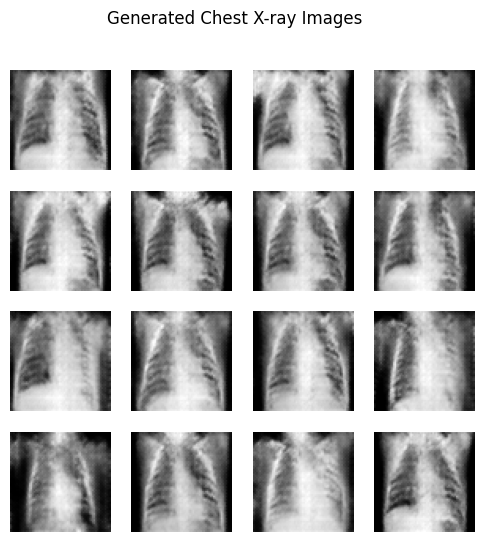

In [40]:

def show_generated_images(generator, device, latent_dim=100, num_images=16):
  #set generator to eval mode
    generator.eval()

    with torch.no_grad():
      #Generate fake images
        noise = torch.randn(num_images, latent_dim, 1, 1).to(device)
        fake_images = generator(noise)

        # convert from [-1,1] to [0,1] #Convert images for display
        fake_images = (fake_images + 1) / 2

        #Plot images
        plt.figure(figsize=(6,6))
        for i in range(num_images):
            plt.subplot(4, 4, i + 1)
            plt.imshow(fake_images[i].cpu().squeeze(), cmap='gray')
            plt.axis('off')

        plt.suptitle("Generated Chest X-ray Images")
        plt.show()

    generator.train()


show_generated_images(generator, device, latent_dim=100, num_images=16)

**Key Takeaways:**
- After training for 50 epochs, the generator produced synthetic chest X-ray images with visible chest structure and lung-like patterns
- The generated images were significantly better than the earlier noisy outputs obtained in lower-epoch experiments
- This indicates that increasing GAN training epochs improved image realism

## **Parameter Variation**


- The GAN was initially trained for 5 epochs, which produced low-quality and noisy images
- Increasing the number of epochs to 20 improved image structure and clarity
- A latent dimension of 100 was used to balance diversity and training stability
- Learning rate was kept at 0.0002, which is commonly used for stable GAN training

**7.4 Plot GAN loss curves**

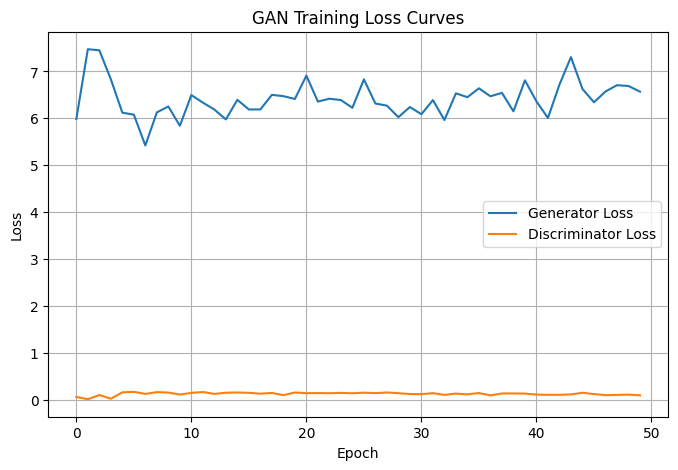

In [41]:
plt.figure(figsize=(8,5))
plt.plot(g_losses, label="Generator Loss")
plt.plot(d_losses, label="Discriminator Loss")
plt.title("GAN Training Loss Curves")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

## **8. Save Generated Images (for augmentation)**

**8.1 Create folders to save images**

In [42]:
save_dir = "/content/drive/MyDrive/ GAN_Xray_Project/synthetic_images"
os.makedirs(save_dir, exist_ok=True)

print("Folder created at:", save_dir)

Folder created at: /content/drive/MyDrive/ GAN_Xray_Project/synthetic_images


**8.2 Function to save generated images**k

In [43]:
from torchvision.utils import save_image

def save_generated_images(generator, device, save_dir, num_images=2000, latent_dim=100):
    generator.eval()

    os.makedirs(save_dir, exist_ok=True)

    count = 0

    with torch.no_grad():
        while count < num_images:
            noise = torch.randn(64, latent_dim, 1, 1).to(device)
            fake_images = generator(noise)

            # convert from [-1,1] to [0,1]
            fake_images = (fake_images + 1) / 2

            for i in range(fake_images.size(0)):
                if count >= num_images:
                    break

                save_path = os.path.join(save_dir, f"fake_{count}.png")
                save_image(fake_images[i], save_path)

                count += 1

    print(f"{num_images} images saved successfully!")


save_generated_images(generator, device, save_dir, num_images=2000)

2000 images saved successfully!


**Key Takeaways:**

- Synthetic chest X-ray images were generated using the trained GAN model
- A total of 2000 images were created and saved to disk
- Images were converted from [-1, 1] to [0, 1] before saving
- These images will be used to augment the training dataset

## **9. Create Augmented Dataset**

**9.1 Add synthetic images to dataset**

In [44]:
import shutil

real_train_dir = "/content/drive/MyDrive/ GAN_Xray_Project/chest_xray/train/NORMAL"
synthetic_dir = save_dir

for file in os.listdir(synthetic_dir):
    shutil.copy(os.path.join(synthetic_dir, file), real_train_dir)

print("Synthetic images added to training dataset!")

Synthetic images added to training dataset!


**Key Takeaways:**
- Doing augmentation helps increase training data
- Helps reduce overfitting
- Helps class imbalance

## **10. Retrain CNN**

**10.1 Move synthetic images into the train folder**

In [45]:
synthetic_dir = "/content/drive/MyDrive/ GAN_Xray_Project/synthetic_images"
target_dir = "/content/drive/MyDrive/ GAN_Xray_Project/chest_xray/train/PNEUMONIA"

files = os.listdir(synthetic_dir)

for file in files:
    shutil.copy(os.path.join(synthetic_dir, file), target_dir)

print("Synthetic images moved to training folder!")

Synthetic images moved to training folder!


**Key Takeaways:**
- Synthetic images were moved into the train/pneumonia class folder because pneumonia class is the most imbalance class amongst two classes.

In [46]:
train_dir = "/content/drive/MyDrive/ GAN_Xray_Project/chest_xray/train"

normal_count = len(os.listdir(train_dir + "/NORMAL"))
pneumonia_count = len(os.listdir(train_dir + "/PNEUMONIA"))

print("NORMAL:", normal_count)
print("PNEUMONIA:", pneumonia_count)

NORMAL: 3342
PNEUMONIA: 5876


**Key Takeaways:**
1. Synthetic images were added to the training dataset to increase the number of training samples
2. After augmentation:
- NORMAL images increased to 3342
- PNEUMONIA images increased to 5876
3. The total augmented training dataset size became 9216
4. This confirms that augmentation was successfully applied

**10.2 Reload the augmented training dataset correctly**

In [47]:
aug_train_dir = "/content/drive/MyDrive/ GAN_Xray_Project/chest_xray/train"

augmented_dataset = datasets.ImageFolder(root=aug_train_dir, transform=transform)
augmented_loader = DataLoader(augmented_dataset, batch_size=32, shuffle=True)

print("New dataset size:", len(augmented_dataset))

New dataset size: 9216


**10.3 Keep validation and test loaders the same**

In [48]:
val_dataset = datasets.ImageFolder(root=data_path + "/val", transform=transform)
test_dataset = datasets.ImageFolder(root=data_path + "/test", transform=transform)

val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

This is because evaluation must be done on real unseen images, not synthetic ones

**10.4 Create a fresh CNN model**

In [49]:
model_aug = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
#Tells the model: mistakes on NORMAL cost 3x more
class_weights = torch.tensor([3.0, 1.0]).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer_aug = torch.optim.Adam(model_aug.parameters(), lr=0.0001)

**Key Takeaways:**

- A fresh CNN model was initialized to ensure fair comparison with the baseline model
- Class Weights tells the CNN to pay more attention to Normal cases during training

**10.5 Train the CNN again on the augmented dataset**

In [51]:
train_losses_aug = []
val_losses_aug = []
train_accuracies_aug = []
val_accuracies_aug = []

num_epochs = 10

for epoch in range(num_epochs):

    # ----- TRAINING -----
    model_aug.train()
    total_train_loss = 0
    correct_train = 0
    total_train = 0

    for images, labels in augmented_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model_aug(images)
        loss = criterion(outputs, labels)

        optimizer_aug.zero_grad()
        loss.backward()
        optimizer_aug.step()

        total_train_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    avg_train_loss = total_train_loss / len(augmented_loader)
    train_acc = 100 * correct_train / total_train

    train_losses_aug.append(avg_train_loss)
    train_accuracies_aug.append(train_acc)

    # ----- VALIDATION -----
    model_aug.eval()
    total_val_loss = 0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model_aug(images)
            loss = criterion(outputs, labels)

            total_val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    avg_val_loss = total_val_loss / len(val_loader)
    val_acc = 100 * correct_val / total_val

    val_losses_aug.append(avg_val_loss)
    val_accuracies_aug.append(val_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.2f}%")

Epoch [1/10] | Train Loss: 0.6354 | Train Acc: 40.04% | Val Loss: 0.5341 | Val Acc: 50.00%
Epoch [2/10] | Train Loss: 0.5716 | Train Acc: 61.86% | Val Loss: 0.5432 | Val Acc: 75.00%
Epoch [3/10] | Train Loss: 0.5525 | Train Acc: 66.63% | Val Loss: 0.4816 | Val Acc: 75.00%
Epoch [4/10] | Train Loss: 0.5419 | Train Acc: 68.65% | Val Loss: 0.5612 | Val Acc: 81.25%
Epoch [5/10] | Train Loss: 0.5225 | Train Acc: 70.11% | Val Loss: 0.4602 | Val Acc: 81.25%
Epoch [6/10] | Train Loss: 0.5143 | Train Acc: 70.51% | Val Loss: 0.4963 | Val Acc: 87.50%
Epoch [7/10] | Train Loss: 0.4977 | Train Acc: 70.86% | Val Loss: 0.5476 | Val Acc: 68.75%
Epoch [8/10] | Train Loss: 0.4813 | Train Acc: 71.77% | Val Loss: 0.4469 | Val Acc: 87.50%
Epoch [9/10] | Train Loss: 0.4657 | Train Acc: 71.55% | Val Loss: 0.5437 | Val Acc: 68.75%
Epoch [10/10] | Train Loss: 0.4471 | Train Acc: 72.19% | Val Loss: 0.3910 | Val Acc: 81.25%


**Key Takeaways:**

- The CNN model was trained for 10 epochs using the augmented dataset

**10.6 Plot augmented training and validation loss**

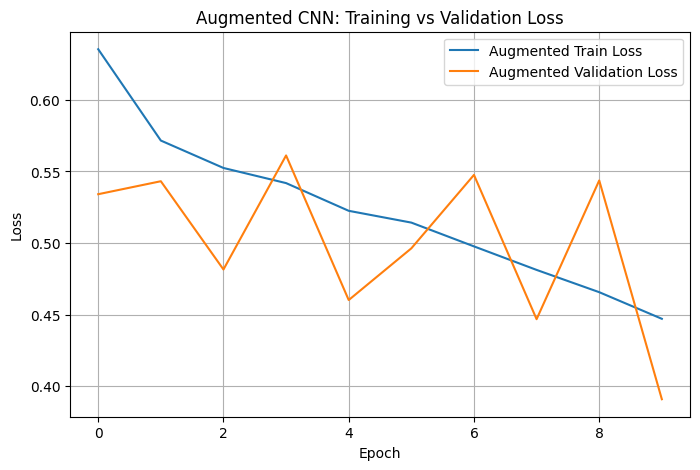

In [52]:


plt.figure(figsize=(8,5))
plt.plot(train_losses_aug, label="Augmented Train Loss")
plt.plot(val_losses_aug, label="Augmented Validation Loss")
plt.title("Augmented CNN: Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

**Key Takeaways:**

- The CNN was retrained for 10 epochs using the augmented dataset
- Training loss decreased from 0.6354 to 0.4471
- Training accuracy increased from 40.04% to 72.19%
- Validation loss decreased overall from 0.5341 to 0.3910
- Validation accuracy improved from 50.00% to 81.25%, with a peak of 87.50%
- These results indicate that the augmented CNN learned more balanced patterns than the original baseline

**10.7 Plot augmented training and validation accuracy**

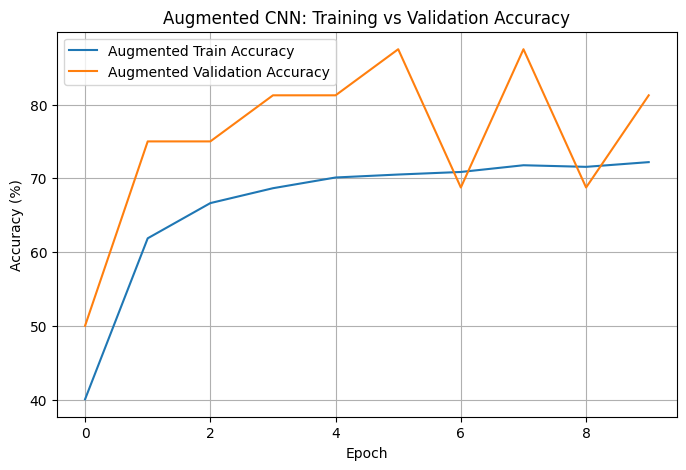

In [53]:
plt.figure(figsize=(8,5))
plt.plot(train_accuracies_aug, label="Augmented Train Accuracy")
plt.plot(val_accuracies_aug, label="Augmented Validation Accuracy")
plt.title("Augmented CNN: Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid()
plt.show()

**Key Takeaways:**

- Training accuracy increased steadily throughout training
- Validation accuracy improved overall and reached a peak of 87.50%
- Compared with earlier augmentation attempts, the final augmented model showed better stability and stronger validation performance

**10.8 Evaluate augmented CNN on the test set**

In [54]:
model_aug.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model_aug(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

aug_test_accuracy = 100 * correct / total
print(f"Augmented Test Accuracy: {aug_test_accuracy:.2f}%")

Augmented Test Accuracy: 82.21%


**Key Takeaways:**

- The augmented CNN achieved a test accuracy of 82.21%
- This is a substantial improvement over the baseline test accuracy of 73.56%
- This indicates that GAN-based augmentation improved classification performance in the final experiment

**10.9 Get confusion matrix and classification report for augmented CNN**

In [55]:
from sklearn.metrics import confusion_matrix, classification_report

all_labels_aug = []
all_preds_aug = []

model_aug.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model_aug(images)
        _, predicted = torch.max(outputs, 1)

        all_labels_aug.extend(labels.cpu().numpy())
        all_preds_aug.extend(predicted.cpu().numpy())

cm_aug = confusion_matrix(all_labels_aug, all_preds_aug)
print("Augmented Confusion Matrix:")
print(cm_aug)

Augmented Confusion Matrix:
[[179  55]
 [ 49 341]]

Augmented Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.79      0.76      0.77       234
   PNEUMONIA       0.86      0.87      0.87       390

    accuracy                           0.83       624
   macro avg       0.82      0.82      0.82       624
weighted avg       0.83      0.83      0.83       624



**Key Takeaways:**

1. For the NORMAL class:
- 179 images were correctly classified
- 55 were misclassified as PNEUMONIA
2. For the PNEUMONIA class:
- 341 images were correctly classified
- 49 were misclassified as NORMAL
3. The augmented model showed much better balance between the two classes than the baseline model

**10.10 Classification Report**

In [56]:
print("\nAugmented Classification Report:")
print(classification_report(all_labels_aug, all_preds_aug, target_names=test_dataset.classes))


Augmented Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.79      0.76      0.77       234
   PNEUMONIA       0.86      0.87      0.87       390

    accuracy                           0.83       624
   macro avg       0.82      0.82      0.82       624
weighted avg       0.83      0.83      0.83       624



**Key Takeaways:**

- The augmented model achieved more balanced performance across both classes
- NORMAL recall improved significantly from 0.32 to 0.76
- PNEUMONIA recall remained strong at 0.87
- Overall classification performance improved, with:
Accuracy = 82.21%
Macro F1-score = 0.82
Weighted F1-score = 0.83
- This shows that final GAN-based augmentation improved both class balance and model generalization

## **11. Analysis of GAN Augmentation**

- The final GAN-augmented CNN outperformed the baseline CNN
- Test accuracy improved from 73.56% to 82.21%
- NORMAL recall improved significantly from 0.32 to 0.76
- Macro F1-score improved from 0.65 to 0.82
- The augmented model achieved more balanced classification across both NORMAL and PNEUMONIA classes

## **12. FINAL CONCLUSION**

- A DCGAN model was implemented to generate synthetic chest X-ray images for data augmentation
- The GAN was trained for 50 epochs, and 2000 synthetic images were generated
- These images were added to the training dataset, increasing the dataset size to 9216
- A CNN classifier was trained on both the original and augmented datasets
- The baseline CNN achieved 73.56% test accuracy
- The augmented CNN achieved 82.21% test accuracy
- The augmented model also improved NORMAL recall from 0.32 to 0.76
- These results show that final GAN-based augmentation improved overall classification performance and class balance